This problem involves simple linear regression without an intercept.

(a) Recall that the coefcient estimate βˆ for the linear regression of
Y onto X without an intercept is given by (3.38). Under what
circumstance is the coefcient estimate for the regression of X
onto Y the same as the coefcient estimate for the regression of
Y onto X?

(b) Generate an example in Python with n = 100 observations in
which the coefcient estimate for the regression of X onto Y
is diferent from the coefcient estimate for the regression of Y
onto X.

(c) Generate an example in Python with n = 100 observations in
which the coefcient estimate for the regression of X onto Y is
the same as the coefcient estimate for the regression of Y onto
X.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.anova import anova_lm
from ISLP.models import summarize, poly
from ISLP.models import ModelSpec as MS
from ISLP import load_data


In [10]:
n = 100
rng = np.random.default_rng(1)
x = rng.normal(size =n)
y = 3 * x + rng.normal(size =n)

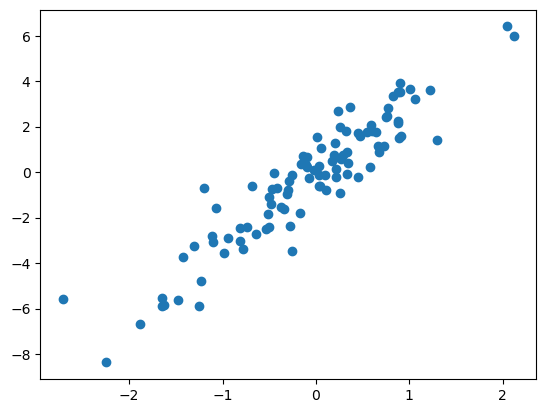

In [11]:
plt.scatter(x,y)

a)Under what
circumstance is the coefcient estimate for the regression of X
onto Y the same as the coefcient estimate for the regression of
Y onto X?

When the data X and Y are the same ( might be shuffled)  (  the same variance or one is the permutation of the other)


b)

In [12]:
df = pd.DataFrame({'x': x, 'y':y})
X = MS('x', intercept=False).fit_transform(df)
results = sm.OLS(y, X).fit()
summarize(results)

,coef,std err,t,P>|t|
x,2.9762,0.117,25.449,0.0


In [13]:
df = pd.DataFrame({'x': x, 'y':y})
Y = MS('y', intercept=False).fit_transform(df)
results = sm.OLS(x, Y).fit()
summarize(results)

,coef,std err,t,P>|t|
y,0.2914,0.011,25.449,0.0


(c) Generate an example in Python with n = 100 observations in
which the coefcient estimate for the regression of X onto Y is
the same as the coefcient estimate for the regression of Y onto
X.

In [20]:
n = 100
rng = np.random.default_rng(1)
x = rng.normal(size =n)
y = rng.permutation(x)



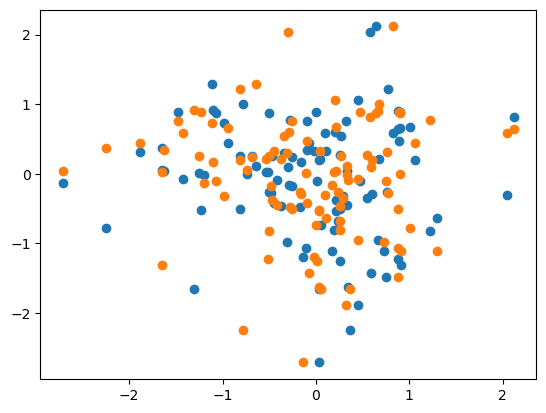

In [21]:
plt.scatter(x,y)
plt.scatter(y,x)

In [22]:
df = pd.DataFrame({'x': x, 'y':y})
Y = MS('y', intercept=False).fit_transform(df)
results = sm.OLS(x, Y).fit()
summarize(results)

,coef,std err,t,P>|t|
y,-0.0565,0.1,-0.563,0.575


In [23]:
df = pd.DataFrame({'x': x, 'y':y})
X = MS('x', intercept=False).fit_transform(df)
results = sm.OLS(y, X).fit()
summarize(results)

,coef,std err,t,P>|t|
x,-0.0565,0.1,-0.563,0.575
